## P300 Detection with SVM on the MOABB BI2013a Dataset

In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import mne
import moabb.datasets
from moabb.paradigms import P300

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC, SVC
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_curve, roc_auc_score, ConfusionMatrixDisplay
)


plt.rcParams.update({'font.size': 12})
np.random.seed(42)

/Users/stepa/Study/master/ml/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Data Loading and Preprocessing

This notebook uses the BI2013a dataset from MOABB and the P300 paradigm.

Preprocessing settings:
- 1-20 Hz band-pass filtering to suppress low-frequency drift and high-frequency noise;
- epoch window from 0.0 to 0.8 s after stimulus onset;
- baseline correction on the interval from 0.0 to 0.2 s;
- resampling to 128 Hz to reduce computation time and stabilize training.

In [ ]:
dataset = moabb.datasets.BI2013a(
    non_adaptive=True,
    adaptive=True,
    training=True,
    online=True,
)

all_subjects = dataset.subject_list
subjects = all_subjects[:8]

paradigm = P300(
    fmin=1,
    fmax=20,
    tmin=0.0,
    tmax=0.8,
    baseline=(0.0, 0.2),
    resample=128,
)

X_raw, y_labels, metadata = paradigm.get_data(dataset=dataset, subjects=subjects)

print('Subjects used:', subjects)
print('X_raw shape:', X_raw.shape) # (n_epochs, n_channels, n_times)
print('Metadata shape:', metadata.shape)
print('Class distribution:')
print(pd.Series(y_labels).value_counts())

Subjects used: [1, 2, 3, 4, 5, 6, 7, 8]
X_raw shape: (80820, 16, 103)
Metadata shape: (80820, 3)
Class distribution:
NonTarget    67350
Target       13470
Name: count, dtype: int64


### EDA

The dataset is expected to be imbalanced, with more NonTarget epochs than Target epochs. Target epochs should also show a positive ERP deflection around 250-500 ms.

,count
NonTarget,67350
Target,13470


Imbalance ratio (major/minor): 5.00


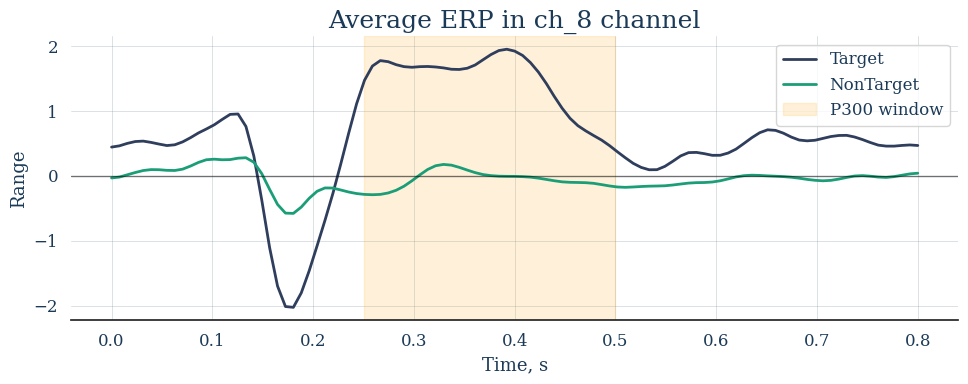

In [18]:
label_counts = pd.Series(y_labels).value_counts()
display(label_counts.to_frame('count'))

class_ratio = label_counts.max() / label_counts.min()
print(f'Imbalance ratio (major/minor): {class_ratio:.2f}')

times = np.linspace(paradigm.tmin, paradigm.tmax, X_raw.shape[-1])

target_mask = (y_labels == 'Target')
nontarget_mask = (y_labels == 'NonTarget')

channel_names = paradigm.channels if paradigm.channels is not None else [f'ch_{i}' for i in range(X_raw.shape[1])]
if 'Cz' in channel_names:
    ch_idx = channel_names.index('Cz')
    ch_name = 'Cz'
else:
    ch_idx = X_raw.shape[1] // 2
    ch_name = channel_names[ch_idx]

target_mean = X_raw[target_mask, ch_idx, :].mean(axis=0)
nontarget_mean = X_raw[nontarget_mask, ch_idx, :].mean(axis=0)

plt.figure(figsize=(10, 4))
plt.plot(times, target_mean, label='Target', linewidth=2)
plt.plot(times, nontarget_mean, label='NonTarget', linewidth=2)
plt.axvspan(0.25, 0.50, color='orange', alpha=0.15, label='P300 window')
plt.axhline(0, color='black', linewidth=1, alpha=0.5)
plt.xlabel('Time, s')
plt.ylabel('Range')
plt.title(f'Average ERP in {ch_name} channel')
plt.legend()
plt.tight_layout()
plt.show()

### Feature Engineering and Rationale

P300 is primarily expressed as a time-localized amplitude change, typically around 250-500 ms after stimulus onset. For this reason, the model uses window-based summary statistics:
- mean values over 0.20-0.35, 0.35-0.50, and 0.50-0.65 s;
- standard deviations over the same windows.

These features are more robust to noise than raw time points and preserve the ERP shape across channels.

In [ ]:
window_defs = [(0.20, 0.35), (0.35, 0.50), (0.50, 0.65)]


def make_window_features(X, times, windows):
    feats = []
    for t0, t1 in windows:
        mask = (times >= t0) & (times < t1)
        seg = X[:, :, mask]  # (n_epochs, n_channels, n_window_times)
        feats.append(seg.mean(axis=2))
        feats.append(seg.std(axis=2))
    return np.hstack(feats)


X = make_window_features(X_raw, times, window_defs)
le = LabelEncoder()
y = le.fit_transform(y_labels)  # NonTarget/Target -> 0/1
groups = metadata['subject'].to_numpy()

print('Feature matrix shape:', X.shape)
print('Classes:', zip(le.classes_, le.transform(le.classes_)))

Feature matrix shape: (80820, 96)
Classes: {np.str_('NonTarget'): np.int64(0), np.str_('Target'): np.int64(1)}


### SVM Training

The linear SVM is used as a baseline on the full dataset. Heavier kernels are evaluated on a reduced subset to keep runtime manageable.
The comparison includes `linear`, `rbf`, and `poly` kernels using the same evaluation metrics.

The confusion matrix is reported for each model. In this task, `Target` is the positive class.

,model,accuracy,precision,recall,f1,roc_auc
2,poly_small,0.69110,0.264482,0.479592,0.340943,0.637311
1,rbf_small,0.69650,0.266462,0.468788,0.339787,0.648561
0,linear_full,0.61622,0.234610,0.575796,0.333382,0.631483


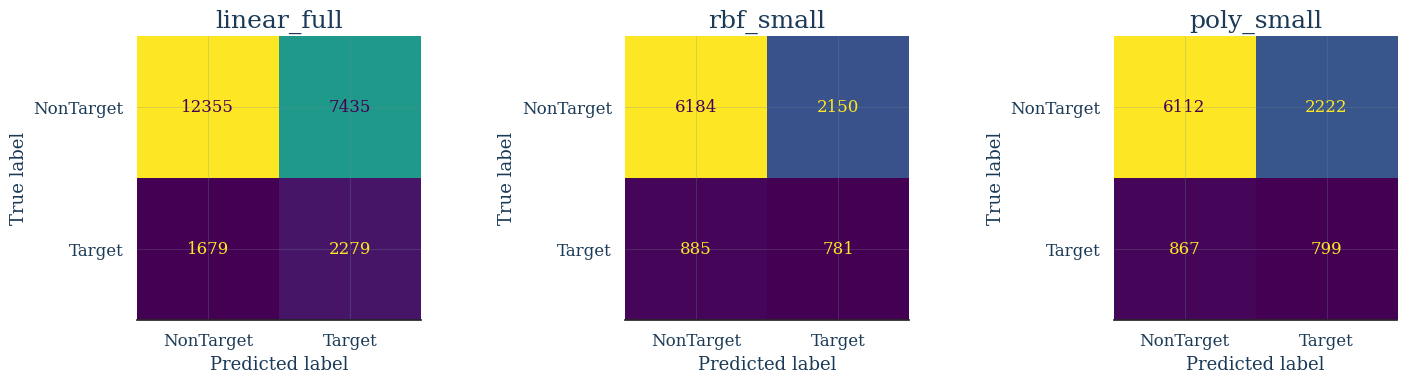

In [ ]:
splitter = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
train_idx, test_idx = next(splitter.split(X, y, groups=groups))

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]


def sample_limited_subset(X_part, y_part, max_samples, random_state=42):
    if len(y_part) <= max_samples:
        return X_part, y_part

    rng = np.random.default_rng(random_state)
    class_ids, class_counts = np.unique(y_part, return_counts=True)
    proportions = class_counts / class_counts.sum()
    target_counts = np.maximum(1, np.floor(proportions * max_samples).astype(int))
    while target_counts.sum() < max_samples:
        target_counts[np.argmax(class_counts - target_counts)] += 1

    sampled_indices = []
    for class_id, count in zip(class_ids, target_counts):
        class_indices = np.where(y_part == class_id)[0]
        chosen = rng.choice(class_indices, size=min(count, len(class_indices)), replace=False)
        sampled_indices.append(chosen)

    sampled_indices = np.concatenate(sampled_indices)
    rng.shuffle(sampled_indices)

    return X_part[sampled_indices], y_part[sampled_indices]


def evaluate_model(name, estimator, X_tr, y_tr, X_te, y_te):
    estimator.fit(X_tr, y_tr)
    y_pred_local = estimator.predict(X_te)
    if hasattr(estimator, 'decision_function'):
        y_score_local = estimator.decision_function(X_te)
    elif hasattr(estimator, 'predict_proba'):
        y_score_local = estimator.predict_proba(X_te)[:, 1]
    else:
        y_score_local = y_pred_local

    return {
        'model': name,
        'accuracy': accuracy_score(y_te, y_pred_local),
        'precision': precision_score(y_te, y_pred_local),
        'recall': recall_score(y_te, y_pred_local),
        'f1': f1_score(y_te, y_pred_local),
        'roc_auc': roc_auc_score(y_te, y_score_local),
        'y_pred': y_pred_local,
        'y_score': y_score_local,
        'y_true': y_te,
    }

X_train_small, y_train_small = sample_limited_subset(X_train, y_train, max_samples=25000, random_state=42)
X_test_small, y_test_small = sample_limited_subset(X_test, y_test, max_samples=10000, random_state=42)

linear_result = evaluate_model(
    'linear_full',
    Pipeline([
        ('scaler', StandardScaler()),
        ('svc', LinearSVC(C=1.0, class_weight='balanced', dual='auto', random_state=42))
    ]),
    X_train, y_train, X_test, y_test
)

rbf_result = evaluate_model(
    'rbf_small',
    Pipeline([
        ('scaler', StandardScaler()),
        ('svc', SVC(kernel='rbf', C=5.0, gamma='scale', class_weight='balanced'))
    ]),
    X_train_small, y_train_small, X_test_small, y_test_small
)

poly_result = evaluate_model(
    'poly_small',
    Pipeline([
        ('scaler', StandardScaler()),
        ('svc', SVC(kernel='poly', degree=3, C=3.0, gamma='scale', coef0=1.0, class_weight='balanced'))
    ]),
    X_train_small, y_train_small, X_test_small, y_test_small
)

results_df = pd.DataFrame([
    {k: linear_result[k] for k in ['model', 'accuracy', 'precision', 'recall', 'f1', 'roc_auc']},
    {k: rbf_result[k] for k in ['model', 'accuracy', 'precision', 'recall', 'f1', 'roc_auc']},
    {k: poly_result[k] for k in ['model', 'accuracy', 'precision', 'recall', 'f1', 'roc_auc']},
]).sort_values('f1', ascending=False)
display(results_df)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, result in zip(axes, [linear_result, rbf_result, poly_result]):
    ConfusionMatrixDisplay.from_predictions(
        result['y_true'],
        result['y_pred'],
        display_labels=le.classes_,
        ax=ax,
        colorbar=False,
    )
    ax.set_title(result['model'])

plt.tight_layout()
plt.show()

model_results = {
    'linear_full': linear_result,
    'rbf_small': rbf_result,
    'poly_small': poly_result,
}

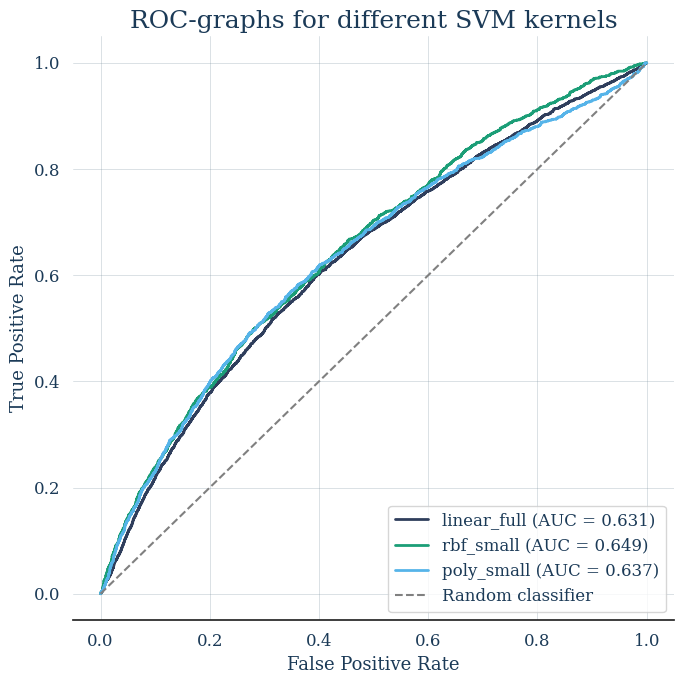

In [17]:
plt.figure(figsize=(7, 7))
for name, result in model_results.items():
    fpr_local, tpr_local, _ = roc_curve(result['y_true'], result['y_score'])
    plt.plot(fpr_local, tpr_local, linewidth=2, label=f"{name} (AUC = {result['roc_auc']:.3f})")

plt.plot([0, 1], [0, 1], '--', color='gray', label='Random classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-graphs for different SVM kernels')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Conclusion

This notebook implements a complete P300 detection pipeline:
- data analysis with MOABB;
- ERP-based feature engineering using time windows;
- SVM training with class imbalance handling;
- evaluation with accuracy, precision, recall, F1, and ROC-AUC.

Possible improvements include richer features, hyperparameter tuning with GridSearchCV, and more rigorous cross-subject validation.